<a href="https://colab.research.google.com/github/Jago56/retail-sales-insights-python/blob/main/retail_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Load the Retail Sales CSV

# New Section

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The original 'url' is no longer needed since we are using a local file.
# url = "https://raw.githubusercontent.com/Jago56/retail-sales-insights-python/main/data/retail_sales.csv"

# Using the actual uploaded filename and pd.read_excel for .xlsx file
df = pd.read_excel('/content/retail_sales.csv (1).xlsx')

# The df.info() output showed that the data was loaded into a single column
# with the header 'date,store_id,product_id,...'.
# This means we need to split this single column into multiple columns.
current_single_column_name = df.columns[0]

# Split the single column by comma into new columns
split_data = df[current_single_column_name].str.split(',', expand=True)

# The header for the split data should be derived from the original single column name
new_column_names = current_single_column_name.split(',')

# Assign the new column names
split_data.columns = new_column_names

# Convert appropriate columns to numeric types if necessary (e.g., units_sold, unit_price, total_sales)
# For now, let's ensure basic data types are correct after splitting

df = split_data # Replace the original df with the correctly split df

# Convert numerical columns to the correct data type
df['units_sold'] = pd.to_numeric(df['units_sold'])
df['unit_price'] = pd.to_numeric(df['unit_price'])
df['total_sales'] = pd.to_numeric(df['total_sales'])

display(df.head())

,date,store_id,product_id,product_name,category,units_sold,unit_price,total_sales,region
0,2024-01-01,101,P001,AlphaPhone,Electronics,10,699,6990,East
1,2024-01-01,102,P002,SmartWatch X,Electronics,18,199,3582,South
2,2024-01-01,103,P003,Laptop Pro,Computers,6,1299,7794,West
3,2024-01-01,104,P004,Tablet Air,Electronics,14,499,6986,North
4,2024-01-02,101,P005,Headphones+,Accessories,32,149,4768,East


### Inspecting the URL Content



In [30]:
import requests

try:
    response = requests.get(url)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
    print("Content from URL (first 500 characters):")
    print(response.text[:500])
except requests.exceptions.RequestException as e:
    print(f"Error fetching URL content: {e}")

Content from URL (first 500 characters):




### Uploading CSV from Local Machine



In [31]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  uploaded_filename = fn

Saving retail_sales.csv.xlsx to retail_sales.csv (2).xlsx
User uploaded file "retail_sales.csv (2).xlsx" with length 10876 bytes


In [13]:
# This cell is now redundant as 'df' has been successfully loaded from the uploaded file
# in cell 'ce81b723' using the correct pandas read function (pd.read_excel).
# The variable 'uploaded_filename' is also now defined.

### Checking for Missing Values

It's important to check for any missing values in the dataset to understand its completeness and decide on appropriate handling strategies.

In [32]:
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found in the dataset.")
else:
    print("Missing values found in the above columns.")

,0


No missing values found in the dataset.


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          40 non-null     object
 1   store_id      40 non-null     object
 2   product_id    40 non-null     object
 3   product_name  40 non-null     object
 4   category      40 non-null     object
 5   units_sold    40 non-null     int64 
 6   unit_price    40 non-null     int64 
 7   total_sales   40 non-null     int64 
 8   region        40 non-null     object
dtypes: int64(3), object(6)
memory usage: 2.9+ KB


In [34]:
# Calculate average sales by product category
average_sales_by_category = df.groupby('category')['total_sales'].mean().reset_index()

# Display the results
display(average_sales_by_category)

,category,total_sales
0,Accessories,6872.625
1,Computers,7794.000
2,Electronics,7502.500


### Average Sales by Product Category Visualization

This bar chart visualizes the average total sales for each product category, allowing for a quick comparison of their performance.

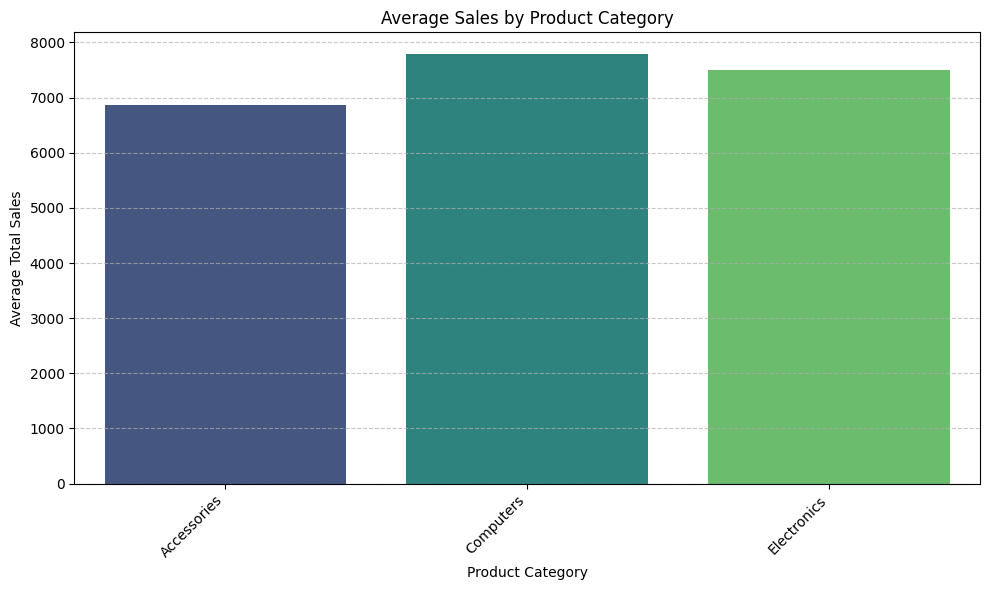

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(x='category', y='total_sales', data=average_sales_by_category, palette='viridis', hue='category', legend=False)
plt.title('Average Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Total Sales')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Total Units Sold by Region

This section calculates and displays the total number of units sold for each geographical region present in the dataset.

In [35]:
total_units_sold_by_region = df.groupby('region')['units_sold'].sum().reset_index()
display(total_units_sold_by_region)

,region,units_sold
0,East,214
1,North,209
2,South,204
3,West,230


In [36]:
highest_sales_region = total_units_sold_by_region.loc[total_units_sold_by_region['units_sold'].idxmax()]
print(f"The region with the highest number of units sold is: {highest_sales_region['region']} with {highest_sales_region['units_sold']} units.")

The region with the highest number of units sold is: West with 230 units.
